In [1]:
!pip install -q timm scikit-learn seaborn

import os
import random
import time
import shutil
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import torchvision.models as tv_models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

CLASS_NAMES = ["Healthy_Leaf", "Leaf_Rot", "Leaf_Spot"]
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 25
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
PATIENCE = 7

DATASET_ROOT = None
for root in ["/kaggle/input", "./data", "."]:
    for dirpath, dirnames, _ in os.walk(root):
        if "Original_Dataset" in dirnames:
            DATASET_ROOT = Path(dirpath) / "Original_Dataset"
            break
    if DATASET_ROOT is not None:
        break

print("Original dataset path:", DATASET_ROOT)
assert DATASET_ROOT is not None, "Original_Dataset not found."

Device: cuda
GPU: Tesla T4
Original dataset path: /kaggle/input/datasets/marjukibnabelayet/cse438-group4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset


In [3]:
SPLIT_ROOT = Path("/kaggle/working/split_dataset_cbam_densenet121")

if not SPLIT_ROOT.exists():
    print("Creating train/val/test splits...")
    for cls in CLASS_NAMES:
        all_imgs = sorted(list((DATASET_ROOT / cls).glob("*.jpg")) +
                          list((DATASET_ROOT / cls).glob("*.jpeg")) +
                          list((DATASET_ROOT / cls).glob("*.png")))
        
        train_imgs, temp_imgs = train_test_split(
            all_imgs, test_size=0.30, random_state=SEED
        )
        val_imgs, test_imgs = train_test_split(
            temp_imgs, test_size=0.50, random_state=SEED
        )

        for split_name, imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
            dest = SPLIT_ROOT / split_name / cls
            dest.mkdir(parents=True, exist_ok=True)
            for src in imgs:
                shutil.copy(src, dest / src.name)

print("Split root:", SPLIT_ROOT)

for split in ["train", "val", "test"]:
    total = 0
    for cls in CLASS_NAMES:
        total += len(list((SPLIT_ROOT / split / cls).glob("*.*")))
    print(f"{split}: {total}")

Creating train/val/test splits...
Split root: /kaggle/working/split_dataset_cbam_densenet121
train: 1425
val: 305
test: 307


In [4]:
MEAN_RGB = [0.485, 0.456, 0.406]
STD_RGB  = [0.229, 0.224, 0.225]
MEAN_EDGE = [0.5]
STD_EDGE  = [0.5]

class EarlyFusionTransform:
    def __init__(self, is_train=True):
        self.is_train = is_train
        self.resize = transforms.Resize((IMG_SIZE, IMG_SIZE))
        self.to_tensor = transforms.ToTensor()
        
        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15, hue=0.03),
            transforms.RandomGrayscale(p=0.05),
        ])
        
        self.norm_rgb = transforms.Normalize(MEAN_RGB, STD_RGB)
        self.norm_edge = transforms.Normalize(MEAN_EDGE, STD_EDGE)

    def _edge_channel(self, pil_img):
        edge_img = pil_img.convert("L").filter(ImageFilter.FIND_EDGES)
        edge_t = self.to_tensor(edge_img)
        edge_t = self.norm_edge(edge_t)
        return edge_t

    def __call__(self, pil_img):
        img = self.resize(pil_img)
        if self.is_train:
            img = self.aug(img)

        rgb_t = self.norm_rgb(self.to_tensor(img))
        edge_t = self._edge_channel(img)

        fused = torch.cat([rgb_t, edge_t], dim=0)   # [4, H, W]
        return fused

train_transform = EarlyFusionTransform(is_train=True)
val_transform   = EarlyFusionTransform(is_train=False)

In [5]:
class BetelLeafFusionDataset(Dataset):
    def __init__(self, root_dir, class_names, transform=None):
        self.root_dir = Path(root_dir)
        self.class_names = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.transform = transform
        self.samples = []

        for cls in class_names:
            folder = self.root_dir / cls
            if not folder.exists():
                continue
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
                for p in sorted(folder.glob(ext)):
                    self.samples.append((str(p), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = BetelLeafFusionDataset(SPLIT_ROOT / "train", CLASS_NAMES, train_transform)
val_ds   = BetelLeafFusionDataset(SPLIT_ROOT / "val",   CLASS_NAMES, val_transform)
test_ds  = BetelLeafFusionDataset(SPLIT_ROOT / "test",  CLASS_NAMES, val_transform)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

labels_train = [s[1] for s in train_ds.samples]
class_counts = Counter(labels_train)
sample_weights = [1.0 / class_counts[label] for label in labels_train]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

imgs, labels = next(iter(train_loader))
print("Batch image shape:", imgs.shape)
print("Batch labels shape:", labels.shape)

Train: 1425 Val: 305 Test: 307
Batch image shape: torch.Size([32, 4, 224, 224])
Batch labels shape: torch.Size([32])


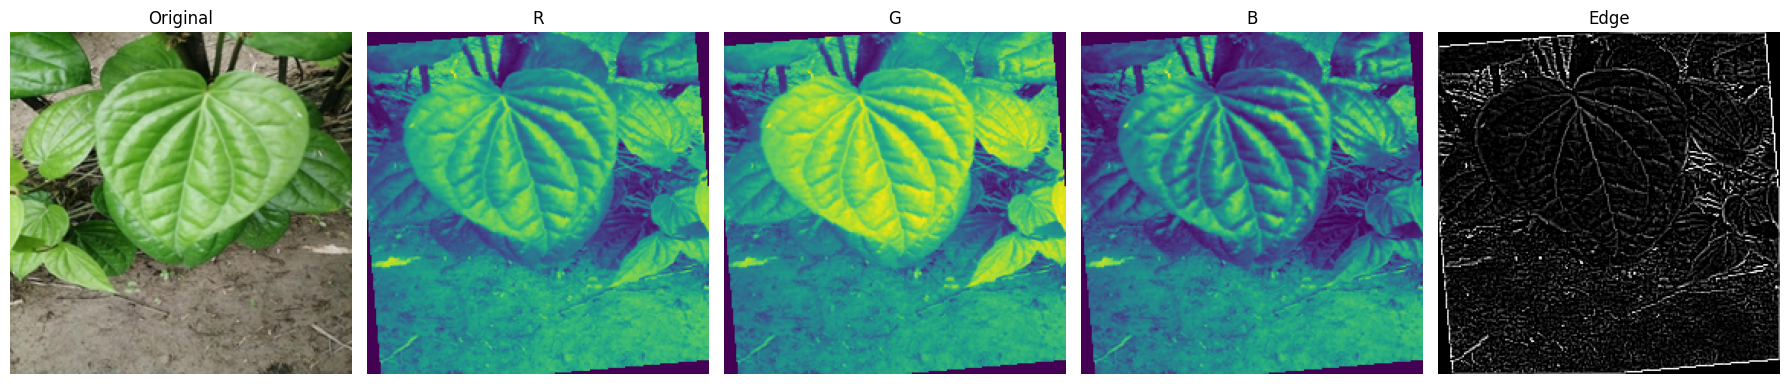

Class: Healthy_Leaf


In [6]:
sample_img, sample_label = train_ds[0]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(Image.open(train_ds.samples[0][0]).convert("RGB").resize((224, 224)))
axes[0].set_title("Original")
axes[0].axis("off")

for i, title in enumerate(["R", "G", "B", "Edge"]):
    axes[i+1].imshow(sample_img[i].numpy(), cmap="gray" if i == 3 else None)
    axes[i+1].set_title(title)
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()
print("Class:", CLASS_NAMES[sample_label])

In [7]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(in_channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, in_channels, kernel_size=1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(F.adaptive_avg_pool2d(x, 1))
        max_out = self.mlp(F.adaptive_max_pool2d(x, 1))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x_cat))

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction=reduction)
        self.sa = SpatialAttention(kernel_size=spatial_kernel)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

In [8]:
class DenseNet121_CBAM_EarlyFusion(nn.Module):
    def __init__(self, num_classes=3, dropout=0.35):
        super().__init__()

        self.backbone = tv_models.densenet121(
            weights=tv_models.DenseNet121_Weights.IMAGENET1K_V1
        )

        old_conv = self.backbone.features.conv0
        new_conv = nn.Conv2d(
            4, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight
            new_conv.weight[:, 3:4, :, :] = old_conv.weight.mean(dim=1, keepdim=True)

        self.backbone.features.conv0 = new_conv

        self.cbam = CBAM(in_channels=1024, reduction=16, spatial_kernel=7)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone.features(x)                  # [B, 1024, 7, 7]
        x = F.relu(x, inplace=True)
        x = self.cbam(x)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = DenseNet121_CBAM_EarlyFusion(num_classes=NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model: DenseNet121 + CBAM (Early Fusion)")
print("Total params:", f"{total_params:,}")
print("Trainable params:", f"{trainable_params:,}")

dummy = torch.randn(2, 4, IMG_SIZE, IMG_SIZE).to(DEVICE)
out = model(dummy)
print("Output shape:", out.shape)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 143MB/s] 


Model: DenseNet121 + CBAM (Early Fusion)
Total params: 8,639,501
Trainable params: 8,639,501
Output shape: torch.Size([2, 3])


In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

CKPT_PATH = "/kaggle/working/best_densenet121_cbam_early_fusion.pth"

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, total_correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        preds = outputs.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        total_correct += (preds == labels).sum().item()
        total += imgs.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / total,
        total_correct / total,
        np.array(all_preds),
        np.array(all_labels)
    )

In [11]:
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "val_f1": [], "lr": []
}

best_val_loss = float("inf")
best_val_acc = 0.0
no_improve = 0

print(f"{'Epoch':>5} {'Train Loss':>12} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>10} {'Val F1':>10} {'LR':>10}")
print("-" * 75)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, criterion, DEVICE)
    val_f1 = f1_score(val_true, val_preds, average="weighted", zero_division=0)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    save_mark = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        no_improve = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_acc": val_acc
        }, CKPT_PATH)
        save_mark = "  [SAVED]"
    else:
        no_improve += 1

    print(f"{epoch:>5} {train_loss:>12.4f} {train_acc*100:>9.2f}% {val_loss:>10.4f} {val_acc*100:>9.2f}% {val_f1:>10.4f} {current_lr:>10.2e}{save_mark}")

    scheduler.step()

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nTraining finished in {(time.time() - start_time)/60:.2f} minutes")
print("Best val acc:", f"{best_val_acc*100:.2f}%")
print("Best val loss:", f"{best_val_loss:.4f}")

Epoch   Train Loss  Train Acc   Val Loss    Val Acc     Val F1         LR
---------------------------------------------------------------------------
    1       0.8373     72.14%     0.5313     87.87%     0.8809   1.00e-04  [SAVED]
    2       0.4749     90.74%     0.4952     90.16%     0.9026   9.96e-05  [SAVED]
    3       0.4175     93.75%     0.4573     91.15%     0.9119   9.84e-05  [SAVED]
    4       0.4091     94.32%     0.4593     91.80%     0.9189   9.65e-05
    5       0.3881     95.37%     0.4485     91.80%     0.9187   9.39e-05  [SAVED]
    6       0.3797     95.72%     0.4428     92.46%     0.9237   9.05e-05  [SAVED]
    7       0.3845     95.72%     0.4398     92.46%     0.9246   8.66e-05  [SAVED]
    8       0.3639     96.98%     0.4272     93.11%     0.9315   8.21e-05  [SAVED]
    9       0.3531     97.19%     0.4243     93.11%     0.9314   7.70e-05  [SAVED]
   10       0.3518     97.68%     0.4303     94.43%     0.9444   7.16e-05
   11       0.3433     97.47%     0.43

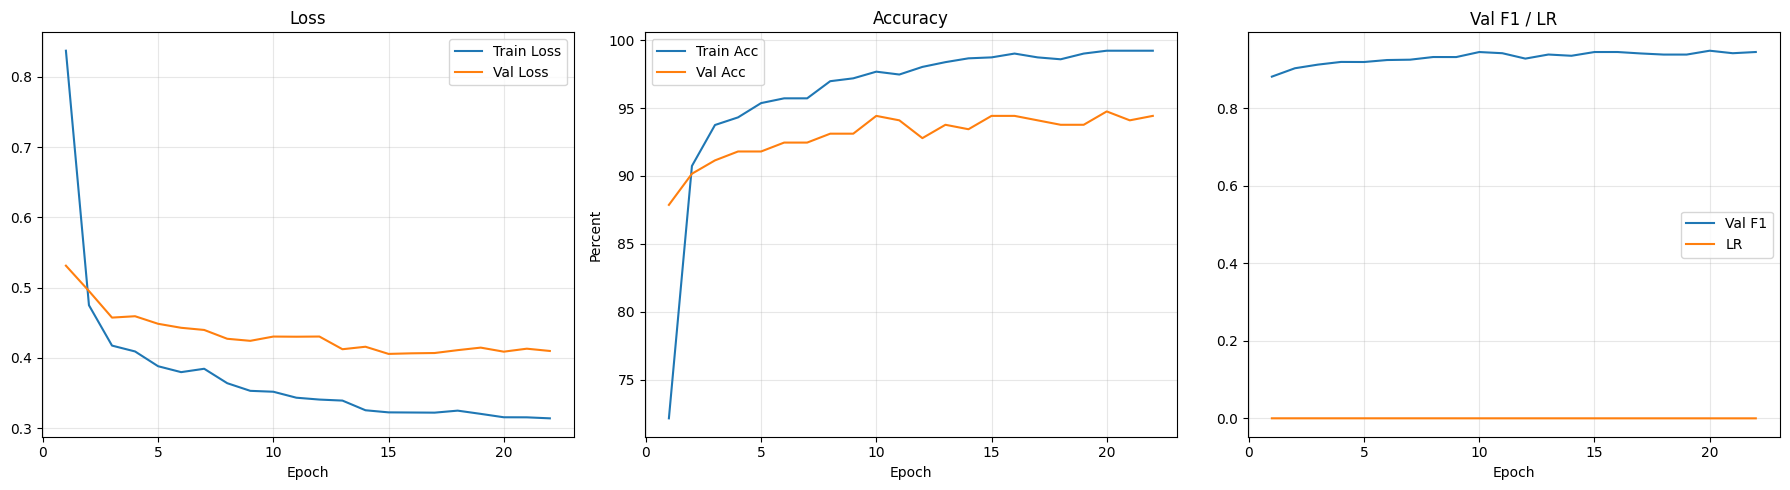

In [12]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs_ran, history["train_loss"], label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(epochs_ran, [x * 100 for x in history["train_acc"]], label="Train Acc")
plt.plot(epochs_ran, [x * 100 for x in history["val_acc"]], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Percent")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(epochs_ran, history["val_f1"], label="Val F1")
plt.plot(epochs_ran, history["lr"], label="LR")
plt.title("Val F1 / LR")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print("Loaded best checkpoint from epoch:", ckpt["epoch"])

test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader, criterion, DEVICE)

weighted_f1 = f1_score(test_true, test_preds, average="weighted", zero_division=0)
macro_f1 = f1_score(test_true, test_preds, average="macro", zero_division=0)

print("\nFINAL TEST RESULTS")
print("=" * 50)
print("Test Accuracy :", f"{test_acc*100:.2f}%")
print("Weighted F1   :", f"{weighted_f1:.4f}")
print("Macro F1      :", f"{macro_f1:.4f}")
print("Test Loss     :", f"{test_loss:.4f}")
print("=" * 50)

print("\nClassification Report:\n")
print(classification_report(test_true, test_preds, target_names=CLASS_NAMES, digits=4))

Loaded best checkpoint from epoch: 15

FINAL TEST RESULTS
Test Accuracy : 95.11%
Weighted F1   : 0.9512
Macro F1      : 0.9435
Test Loss     : 0.3750

Classification Report:

              precision    recall  f1-score   support

Healthy_Leaf     0.9689    0.9630    0.9659       162
    Leaf_Rot     0.9268    0.9268    0.9268        41
   Leaf_Spot     0.9333    0.9423    0.9378       104

    accuracy                         0.9511       307
   macro avg     0.9430    0.9440    0.9435       307
weighted avg     0.9513    0.9511    0.9512       307



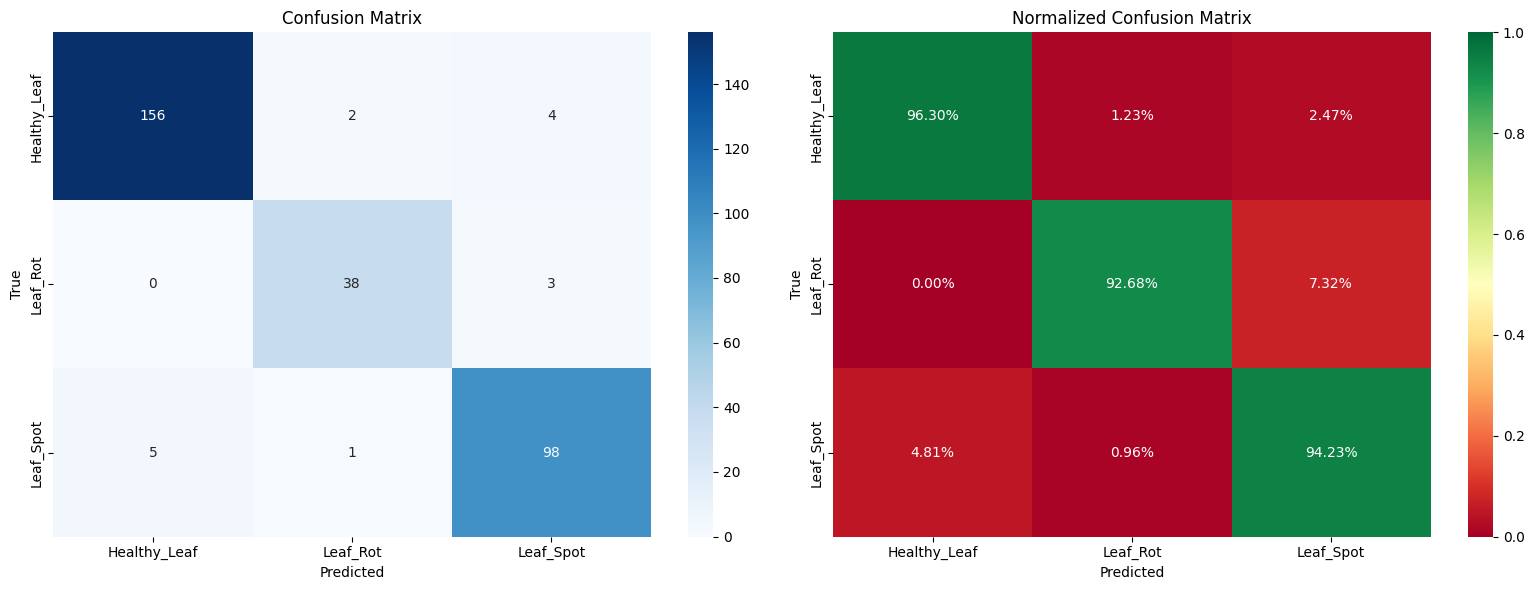

In [14]:
cm = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="RdYlGn",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

,Class,Precision,Recall,F1
0,Healthy_Leaf,0.968944,0.962963,0.965944
1,Leaf_Rot,0.926829,0.926829,0.926829
2,Leaf_Spot,0.933333,0.942308,0.937799


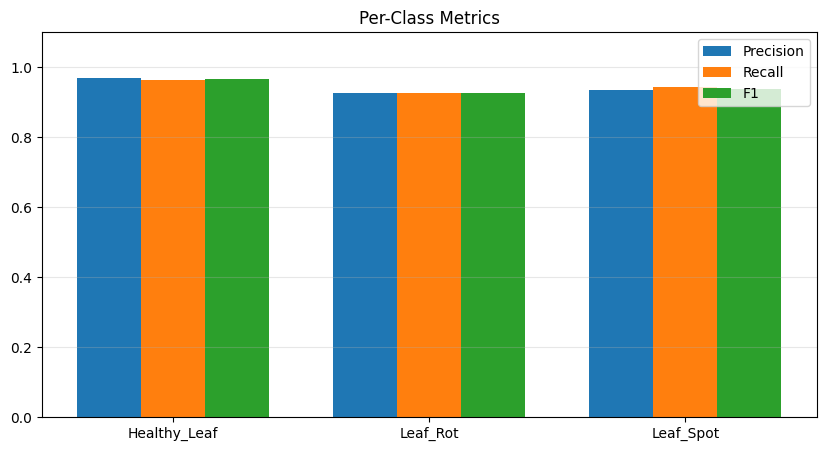

In [15]:
per_prec = precision_score(test_true, test_preds, average=None, zero_division=0)
per_rec  = recall_score(test_true, test_preds, average=None, zero_division=0)
per_f1   = f1_score(test_true, test_preds, average=None, zero_division=0)

df_metrics = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": per_prec,
    "Recall": per_rec,
    "F1": per_f1
})

display(df_metrics)

x = np.arange(len(CLASS_NAMES))
w = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - w, per_prec, width=w, label="Precision")
plt.bar(x, per_rec, width=w, label="Recall")
plt.bar(x + w, per_f1, width=w, label="F1")
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.1)
plt.title("Per-Class Metrics")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

In [16]:
FINAL_MODEL_PATH = "/kaggle/working/densenet121_cbam_early_fusion_final.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE
}, FINAL_MODEL_PATH)

print("Saved model to:", FINAL_MODEL_PATH)

Saved model to: /kaggle/working/densenet121_cbam_early_fusion_final.pth
